<a href="https://colab.research.google.com/github/YassineGasmi04/AdultProject-ML-/blob/main/TP_capital_gain_membre6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Préparation de données et sélection des caractéristiques – Membre 6**

### **Contexte**
| Élément | Description |
|---|---|
| **Utilisateur visé** | Un organisme d'éducation financière |
| **Objectif métier** | Repérer les profils susceptibles de disposer de revenus du capital, pour cibler des actions de sensibilisation à l'épargne et à l'investissement |
| **Objectif Data Science** | Classification binaire de `capital-gain > 0` (a des gains ou non) |
| **Variables créées** | tranche d'âge, indicateur « marié », niveau d'études regroupé |

### **Dataset utilisé**
Adult Census Income (UCI) : 15 variables socio-démographiques décrivant des individus recensés aux États-Unis.

### **Démarche (même structure que le TP)**
1. Exploration  2. Nettoyage  3. Création de la cible et des nouvelles variables  4. Transformation  5. Sélection des caractéristiques **principales** et **secondaires**

**Importer les bibliothèques nécessaires**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_classif

**Charger le dataset**

Le code harmonise les noms de colonnes (certaines versions utilisent `capital.gain`, `capital_gain`, `educational-num` ou `gender`) et gère le cas d'un fichier sans en-tête. Remplacer le nom du fichier si besoin.

In [4]:
FICHIER = "adult.data"   # <-- mettre ici le nom de votre fichier

COLONNES = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
            'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
            'hours-per-week', 'native-country', 'income']

df = pd.read_csv(FICHIER, skipinitialspace=True, na_values='?')

# Fichier sans en-tête (ex. adult.data) : la première ligne a été lue comme en-tête
if 'age' not in [str(c).strip().lower() for c in df.columns]:
    df = pd.read_csv(FICHIER, header=None, names=COLONNES, skipinitialspace=True, na_values='?')

# Harmonisation des noms de colonnes
df.columns = (df.columns.str.strip().str.lower()
              .str.replace('.', '-', regex=False).str.replace('_', '-', regex=False))
df = df.rename(columns={'educational-num': 'education-num', 'gender': 'sex'})

# Nettoyage des chaînes : espaces, '?' et point final de la version test ('>50K.')
for col in df.select_dtypes(exclude='number').columns:
    df[col] = df[col].str.strip().replace('?', np.nan)
df['income'] = df['income'].str.replace('.', '', regex=False)

print(df.shape)

(32561, 15)


**Exploration et aperçu des données**

In [5]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [6]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [7]:
df.tail()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


In [8]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


# **Partie 1 : Nettoyage de données**

### **Gestion des doublons**

1- Détection des doublons

In [10]:
print("Nombre de doublons :", df.duplicated().sum())

Nombre de doublons : 24


2- Supprimer les doublons

In [11]:
df.drop_duplicates(inplace=True)

3- Vérifier après suppression des doublons

In [12]:
print("Nombre de doublons :", df.duplicated().sum())
print("Taille :", df.shape)

Nombre de doublons : 0
Taille : (32537, 15)


## **Gestion des valeurs manquantes**

Dans ce dataset, les valeurs manquantes sont codées `?` (converties en `NaN` au chargement). Elles concernent `workclass`, `occupation` et `native-country`.

In [13]:
print("Valeurs manquantes :")
print(df.isnull().sum())
print("\nEn % :")
print((df.isnull().mean() * 100).round(2))

Valeurs manquantes :
age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     582
income               0
dtype: int64

En % :
age               0.00
workclass         5.64
fnlwgt            0.00
education         0.00
education-num     0.00
marital-status    0.00
occupation        5.66
relationship      0.00
race              0.00
sex               0.00
capital-gain      0.00
capital-loss      0.00
hours-per-week    0.00
native-country    1.79
income            0.00
dtype: float64


Ces trois variables sont **catégorielles**. On remplace les manquants par une modalité `Unknown` plutôt que par le mode : on ne supprime aucune ligne et on ne crée pas d'information fausse (l'absence de réponse peut elle-même être informative).

In [14]:
for col in ['workclass', 'occupation', 'native-country']:
    df[col] = df[col].fillna('Unknown')

print("Valeurs manquantes restantes :", df.isnull().sum().sum())

Valeurs manquantes restantes : 0


**Visualisation des données**

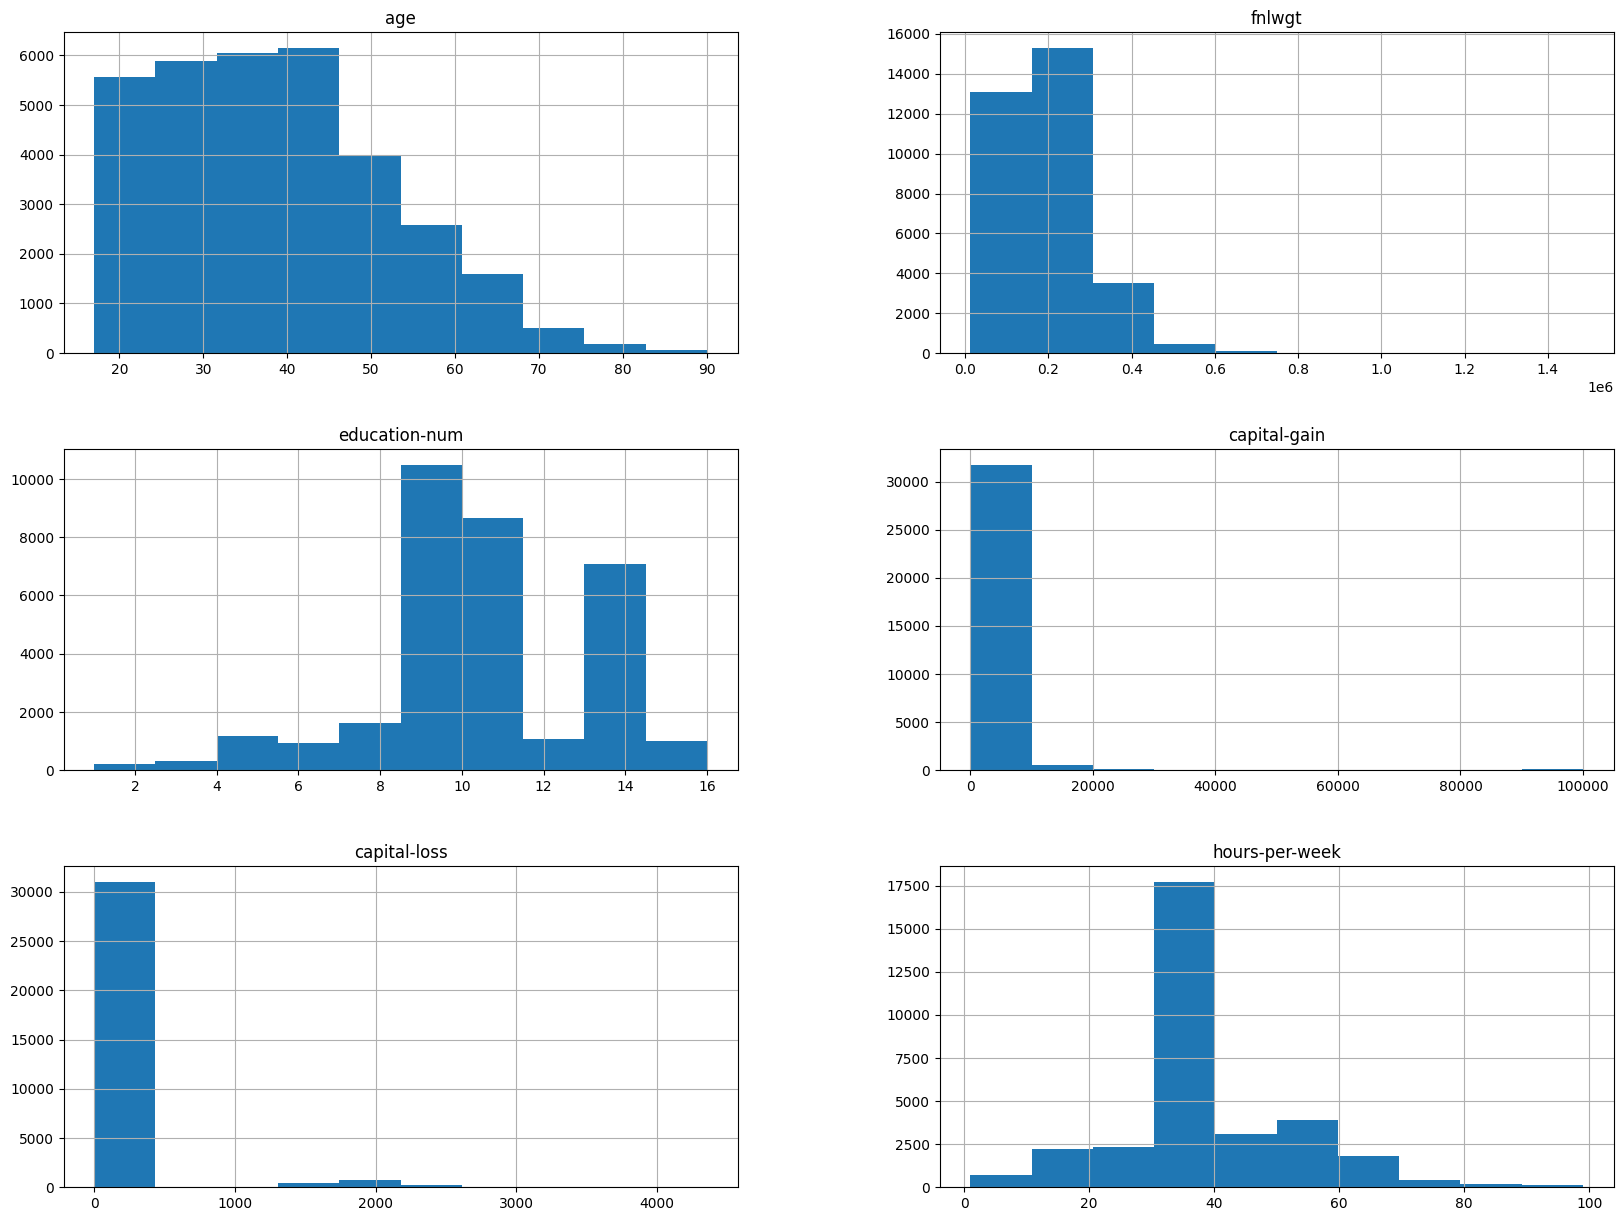

In [15]:
df.hist(figsize=(20, 15))
plt.show()

On remarque que `capital-gain` est extrêmement asymétrique : la grande majorité des valeurs vaut 0. C'est ce qui justifie de reformuler la cible en **binaire** (`capital-gain > 0`) plutôt qu'en régression.

# **Partie 2 : Création de la cible et des nouvelles variables**

### **Variable cible : `has_capital_gain`**

has_capital_gain
0    29825
1     2712
Name: count, dtype: int64

Proportions :
has_capital_gain
0    0.9166
1    0.0834
Name: proportion, dtype: float64


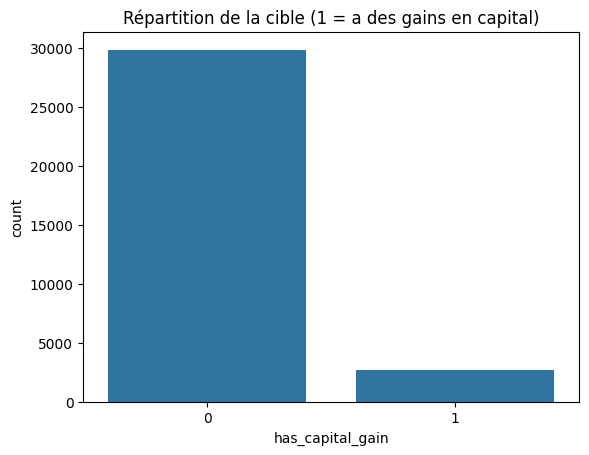

In [16]:
df['has_capital_gain'] = (df['capital-gain'] > 0).astype(int)
target = 'has_capital_gain'

print(df[target].value_counts())
print("\nProportions :")
print(df[target].value_counts(normalize=True).round(4))

sns.countplot(x=target, data=df)
plt.title("Répartition de la cible (1 = a des gains en capital)")
plt.show()

**Remarque :** la cible est **déséquilibrée** (environ 8 % de positifs). À la modélisation, il faudra utiliser un découpage stratifié, des métriques adaptées (rappel, F1, AUC plutôt que l'accuracy seule) et éventuellement `class_weight='balanced'`.

### **Variables créées (feature engineering)**

1. **`tranche_age`** : l'âge découpé en tranches, car le patrimoine s'accumule avec l'âge mais de façon non linéaire.
2. **`est_marie`** : 1 si `marital-status` vaut `Married-civ-spouse` ou `Married-AF-spouse`. Un ménage marié dispose plus souvent d'une épargne commune.
3. **`education_groupe`** : les 16 niveaux de `education` regroupés en 5 niveaux, pour réduire le nombre de modalités tout en gardant l'ordre.

In [17]:
# 1) Tranche d'âge
df['tranche_age'] = pd.cut(df['age'], bins=[16, 25, 35, 45, 55, 65, 100],
                           labels=['17-25', '26-35', '36-45', '46-55', '56-65', '66+'])

# 2) Indicateur « marié »
df['est_marie'] = df['marital-status'].isin(['Married-civ-spouse', 'Married-AF-spouse']).astype(int)

# 3) Niveau d'études regroupé (à partir de education-num, qui est ordonné)
def regrouper_education(n):
    if n <= 8:   return '1-Sans diplome secondaire'
    if n == 9:   return '2-HS-grad'
    if n <= 12:  return '3-Etudes sup. courtes'   # Some-college, Assoc-voc, Assoc-acdm
    if n == 13:  return '4-Bachelors'
    return '5-Master et plus'                        # Masters, Prof-school, Doctorate

df['education_groupe'] = df['education-num'].apply(regrouper_education)

df[['age', 'tranche_age', 'marital-status', 'est_marie', 'education', 'education_groupe']].head(10)

,age,tranche_age,marital-status,est_marie,education,education_groupe
0,39,36-45,Never-married,0,Bachelors,4-Bachelors
1,50,46-55,Married-civ-spouse,1,Bachelors,4-Bachelors
2,38,36-45,Divorced,0,HS-grad,2-HS-grad
3,53,46-55,Married-civ-spouse,1,11th,1-Sans diplome secondaire
4,28,26-35,Married-civ-spouse,1,Bachelors,4-Bachelors
5,37,36-45,Married-civ-spouse,1,Masters,5-Master et plus
6,49,46-55,Married-spouse-absent,0,9th,1-Sans diplome secondaire
7,52,46-55,Married-civ-spouse,1,HS-grad,2-HS-grad
8,31,26-35,Never-married,0,Masters,5-Master et plus
9,42,36-45,Married-civ-spouse,1,Bachelors,4-Bachelors


**Taux de personnes ayant des gains en capital selon les variables créées**

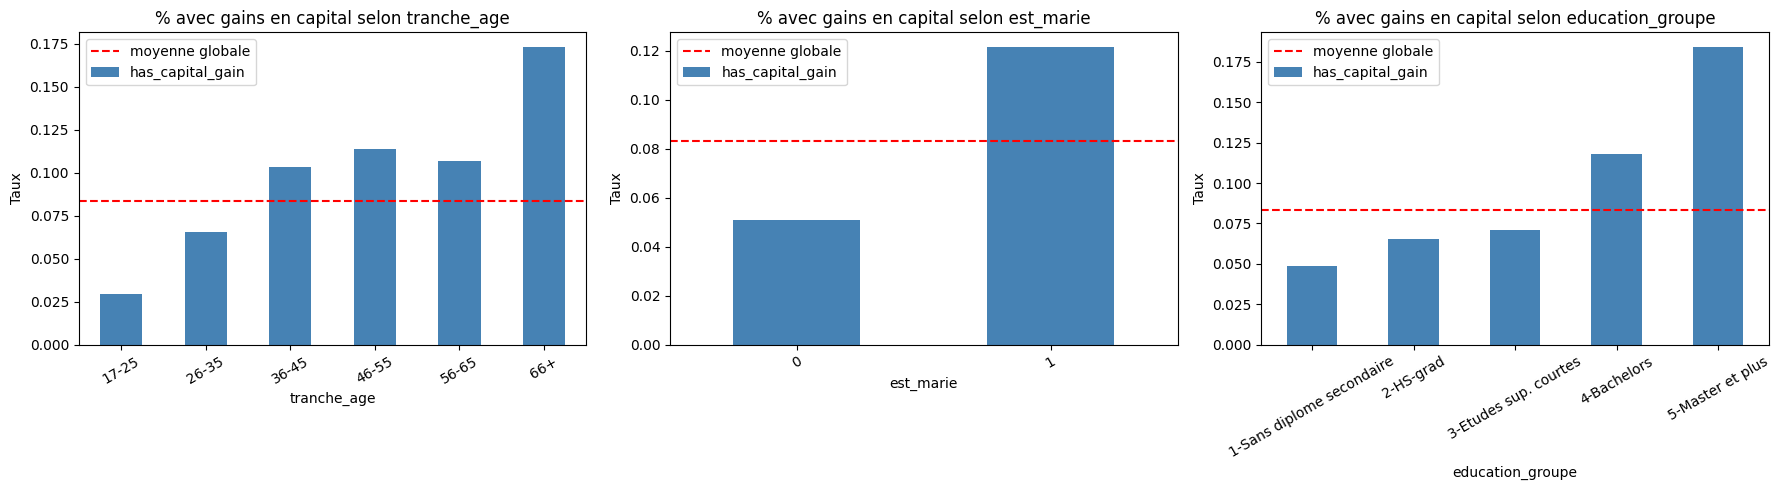

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['tranche_age', 'est_marie', 'education_groupe']):
    taux = df.groupby(col, observed=True)[target].mean().sort_index()
    taux.plot(kind='bar', ax=ax, color='steelblue')
    ax.axhline(df[target].mean(), color='red', linestyle='--', label='moyenne globale')
    ax.set_title(f"% avec gains en capital selon {col}")
    ax.set_ylabel("Taux"); ax.legend(); ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

On observe une progression nette : le taux augmente avec l'âge, est environ deux fois plus élevé chez les personnes mariées, et augmente avec le niveau d'études. Les trois variables créées sont donc **pertinentes** pour la cible.

### **Variables à écarter avant la sélection (risque de fuite de données)**

* **`capital-gain`** : elle **définit** la cible. La garder reviendrait à donner la réponse au modèle.
* **`capital-loss`** : vérifions la table croisée ci-dessous. Aucune personne ayant une perte en capital n'a de gain en capital : le recensement enregistre un montant **net** (gain *ou* perte). C'est une information de la même déclaration que la cible, donc une **fuite**.
* **`income`** : le revenu déclaré **inclut** les gains en capital (un gros gain fait passer mécaniquement au-dessus de 50K). De plus, l'organisme ne connaît généralement pas le revenu des personnes qu'il veut cibler. On l'analyse, mais on ne la retient pas.
* **`fnlwgt`** : poids d'échantillonnage du recensement, ce n'est pas une caractéristique de la personne.

In [19]:
print("Croisement capital-loss > 0 / cible :")
print(pd.crosstab(df['capital-loss'] > 0, df[target]))
print("\nCroisement income / cible (taux par ligne) :")
print(pd.crosstab(df['income'], df[target], normalize='index').round(3))

Croisement capital-loss > 0 / cible :
has_capital_gain      0     1
capital-loss                 
False             28306  2712
True               1519     0

Croisement income / cible (taux par ligne) :
has_capital_gain      0      1
income                        
<=50K             0.958  0.042
>50K              0.786  0.214


# **Partie 3 : Transformation de données**

**Encodage des variables catégorielles** (comme dans le TP, pour la matrice de corrélation)

In [20]:
df_enc = df.copy()
df_enc['tranche_age'] = df_enc['tranche_age'].astype(str)

label_encoders = {}
for col in df_enc.select_dtypes(exclude='number').columns:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))
    label_encoders[col] = le

print("Dataset après encodage des variables catégorielles :")
df_enc.head()

Dataset après encodage des variables catégorielles :


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,has_capital_gain,tranche_age,est_marie,education_groupe
0,39,6,77516,9,13,4,0,1,4,1,2174,0,40,38,0,1,2,0,3
1,50,5,83311,9,13,2,3,0,4,1,0,0,13,38,0,0,3,1,3
2,38,3,215646,11,9,0,5,1,4,1,0,0,40,38,0,0,2,0,1
3,53,3,234721,1,7,2,5,0,2,1,0,0,40,38,0,0,3,1,0
4,28,3,338409,9,13,2,9,5,2,0,0,0,40,4,0,0,1,1,3


**Normalisation**

In [21]:
scaler = StandardScaler()
df_normalized = df_enc.copy()
cols_num = df_enc.select_dtypes(include=[np.number]).columns.drop(target)
df_normalized[cols_num] = scaler.fit_transform(df_enc[cols_num])
df_normalized.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,has_capital_gain,tranche_age,est_marie,education_groupe
0,0.030390,1.876197,-1.063569,-0.335266,1.134777,0.921857,-1.483535,-0.277864,0.393685,0.703020,0.148292,-0.216743,-0.035664,0.257437,-0.563377,1,0.145212,-0.924443,1.107560
1,0.836973,1.175970,-1.008668,-0.335266,1.134777,-0.405919,-0.790564,-0.900126,0.393685,0.703020,-0.145975,-0.216743,-2.222483,0.257437,-0.563377,0,0.878531,1.081733,1.107560
2,-0.042936,-0.224485,0.245040,0.181519,-0.420679,-1.733696,-0.328584,-0.277864,0.393685,0.703020,-0.145975,-0.216743,-0.035664,0.257437,-0.563377,0,0.145212,-0.924443,-0.661025
3,1.056950,-0.224485,0.425752,-2.402406,-1.198407,-0.405919,-0.328584,-0.900126,-1.962488,0.703020,-0.145975,-0.216743,-0.035664,0.257437,-0.563377,0,0.878531,1.081733,-1.545317
4,-0.776193,-0.224485,1.408066,-0.335266,1.134777,-0.405919,0.595376,2.211186,-1.962488,-1.422436,-0.145975,-0.216743,-0.035664,-5.352003,-0.563377,0,-0.588106,1.081733,1.107560


# **Partie 4 : Sélection des caractéristiques**

**Matrice de corrélation**

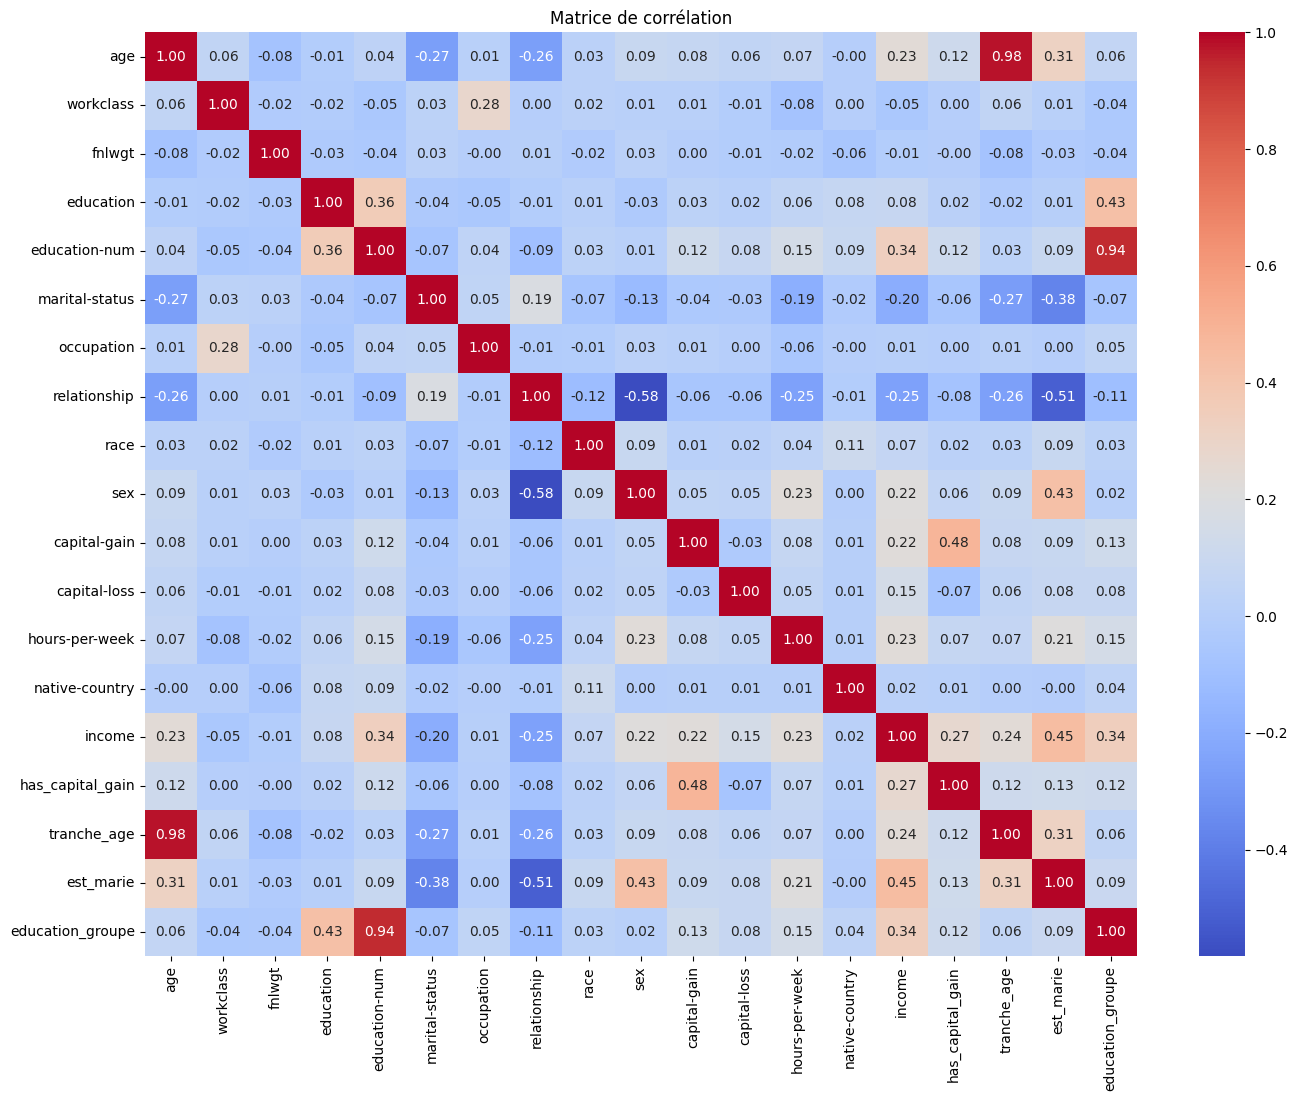

In [22]:
plt.figure(figsize=(16, 12))
corr_matrix = df_normalized.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title('Matrice de corrélation')
plt.show()

**Limite de la corrélation de Pearson ici**

La corrélation de Pearson n'a de sens que pour des variables **numériques ou ordonnées**. Pour une variable nominale encodée avec `LabelEncoder` (ex. `occupation`), les numéros 0, 1, 2… sont arbitraires : la corrélation dépend de l'ordre alphabétique des catégories. On complète donc avec deux mesures adaptées à une cible binaire :

* **Pearson (point-bisériale)** pour les variables numériques et binaires ;
* **V de Cramér** pour les variables catégorielles (basé sur le test du χ²) ;
* **Information mutuelle** pour toutes les variables (capte aussi les liens non linéaires).

In [23]:
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.values.sum()
    r, k = table.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

numeriques = ['age', 'education-num', 'hours-per-week', 'est_marie', 'capital-loss', 'fnlwgt']
categorielles = ['tranche_age', 'education_groupe', 'education', 'marital-status', 'relationship',
                 'occupation', 'workclass', 'sex', 'race', 'native-country', 'income']

lignes = []
for col in numeriques:
    lignes.append([col, 'Pearson', abs(df[col].corr(df[target]))])
for col in categorielles:
    lignes.append([col, 'V de Cramér', cramers_v(df[col], df[target])])
assoc = pd.DataFrame(lignes, columns=['variable', 'mesure', 'association']).set_index('variable')

# Information mutuelle
X_mi = df_enc[numeriques + categorielles]
discretes = [c != 'age' and c != 'hours-per-week' and c != 'fnlwgt' and c != 'capital-loss' for c in X_mi.columns]
mi = mutual_info_classif(X_mi, df_enc[target], discrete_features=discretes, random_state=42)
assoc['info_mutuelle'] = pd.Series(mi, index=X_mi.columns)

assoc = assoc.sort_values('association', ascending=False)
assoc.round(4)

,mesure,association,info_mutuelle
variable,,,
income,V de Cramér,0.2660,0.0298
education,V de Cramér,0.1417,0.0085
relationship,V de Cramér,0.1337,0.0096
education_groupe,V de Cramér,0.1332,0.0077
marital-status,V de Cramér,0.1309,0.0089
tranche_age,V de Cramér,0.1277,0.0088
est_marie,Pearson,0.1274,0.0082
occupation,V de Cramér,0.1217,0.0074
age,Pearson,0.1201,0.0085


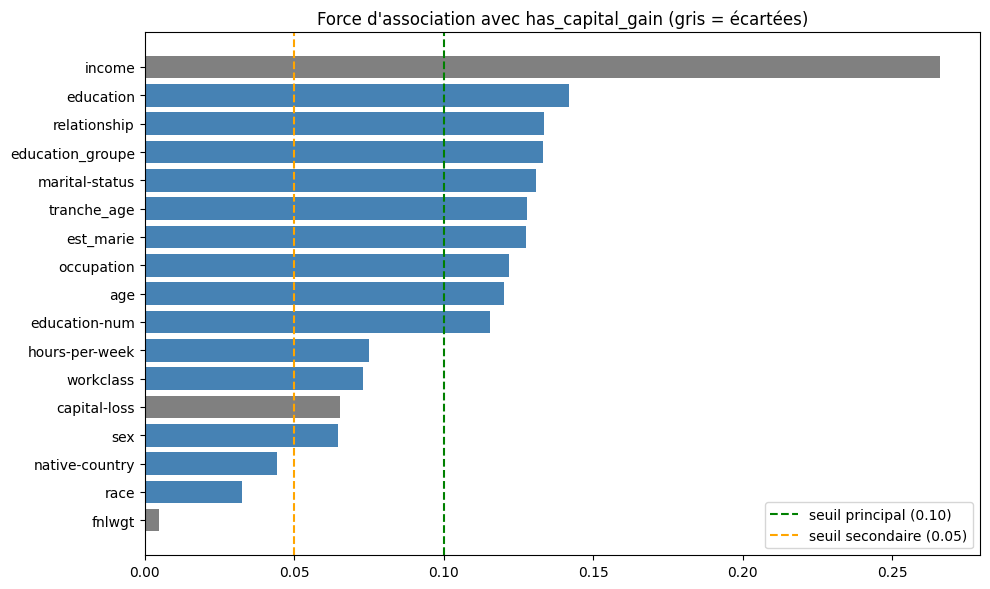

In [24]:
plt.figure(figsize=(10, 6))
couleurs = ['grey' if v in ['income', 'capital-loss', 'fnlwgt'] else 'steelblue' for v in assoc.index]
plt.barh(assoc.index[::-1], assoc['association'][::-1], color=couleurs[::-1])
plt.axvline(0.10, color='green', linestyle='--', label='seuil principal (0.10)')
plt.axvline(0.05, color='orange', linestyle='--', label='seuil secondaire (0.05)')
plt.title("Force d'association avec has_capital_gain (gris = écartées)")
plt.legend(); plt.tight_layout(); plt.show()

**Sélectionner les caractéristiques**

Règles de sélection :
* **Principales** : association ≥ 0.10 ;
* **Secondaires** : 0.05 ≤ association < 0.10 ;
* **Écartées** : association < 0.05, fuite de données, ou **redondance** avec une variable déjà retenue.

Pour la redondance, on garde **une seule variable par information**, en privilégiant les variables créées demandées dans l'objectif Data Science :
* âge → `tranche_age` (on écarte `age`)
* études → `education_groupe` (on écarte `education` et `education-num`)
* situation familiale → `est_marie` (on écarte `marital-status` et `relationship`, très corrélées entre elles : *Husband/Wife* ⇔ marié)

In [25]:
fuites = ['capital-gain', 'capital-loss', 'income', 'fnlwgt']
redondantes = ['age', 'education', 'education-num', 'marital-status', 'relationship']

seuil_principal, seuil_secondaire = 0.10, 0.05
candidats = assoc.drop(index=[v for v in fuites + redondantes if v in assoc.index])

features_principales = candidats[candidats['association'] >= seuil_principal].index.tolist()
features_secondaires = candidats[(candidats['association'] >= seuil_secondaire) &
                                 (candidats['association'] < seuil_principal)].index.tolist()
features_ecartees_faibles = candidats[candidats['association'] < seuil_secondaire].index.tolist()

print("Caractéristiques PRINCIPALES  :", features_principales)
print("Caractéristiques SECONDAIRES  :", features_secondaires)
print("Écartées (lien trop faible)   :", features_ecartees_faibles)
print("Écartées (fuite / non pertinente) :", fuites)
print("Écartées (redondantes)        :", redondantes)

Caractéristiques PRINCIPALES  : ['education_groupe', 'tranche_age', 'est_marie', 'occupation']
Caractéristiques SECONDAIRES  : ['hours-per-week', 'workclass', 'sex']
Écartées (lien trop faible)   : ['native-country', 'race']
Écartées (fuite / non pertinente) : ['capital-gain', 'capital-loss', 'income', 'fnlwgt']
Écartées (redondantes)        : ['age', 'education', 'education-num', 'marital-status', 'relationship']


### **Justification des choix**

| Rôle | Variable | Justification |
|---|---|---|
| **Principale** | `education_groupe` | Le taux de gains en capital passe d'environ 5 % (sans diplôme) à environ 18 % (Master et plus) |
| **Principale** | `tranche_age` | Progression régulière avec l'âge : environ 3 % chez les 17-25 ans contre environ 16 % chez les 66 ans et plus |
| **Principale** | `est_marie` | Environ 12 % chez les mariés contre 5 % chez les autres |
| **Principale** | `occupation` | Les métiers de cadre et les professions intellectuelles ont un taux bien supérieur |
| **Secondaire** | `hours-per-week` | Lien plus faible, apporte une information sur le type d'emploi |
| **Secondaire** | `workclass` | Les indépendants (`Self-emp-inc`) détiennent plus souvent du capital |
| **Secondaire** | `sex` | Lien faible ; à utiliser avec précaution (risque de ciblage discriminant) |
| Écartée | `race`, `native-country` | Lien très faible (< 0.05) et variables sensibles sur le plan éthique |
| Écartée | `capital-gain`, `capital-loss`, `income` | Fuite de données (même information que la cible) |
| Écartée | `fnlwgt` | Poids statistique, aucune signification individuelle |

Les variables principales correspondent exactement à celles annoncées dans l'objectif Data Science (tranche d'âge, indicateur « marié », niveau d'études regroupé), enrichies de `occupation`.

**Créer un DataFrame avec les caractéristiques sélectionnées**

Pour la modélisation, les variables catégorielles nominales sont encodées en **one-hot** (et non avec `LabelEncoder`, qui créerait un ordre artificiel entre les catégories). Les variables numériques sont normalisées.

In [26]:
features_selectionnees = features_principales + features_secondaires

df_selected = df[features_selectionnees + [target]].copy()
df_selected['tranche_age'] = df_selected['tranche_age'].astype(str)

cols_cat = [c for c in features_selectionnees if not pd.api.types.is_numeric_dtype(df_selected[c])]
cols_num = [c for c in features_selectionnees if c not in cols_cat]

df_selected = pd.get_dummies(df_selected, columns=cols_cat, drop_first=True, dtype=int)
df_selected[[c for c in cols_num if c != 'est_marie']] = StandardScaler().fit_transform(
    df_selected[[c for c in cols_num if c != 'est_marie']])

print(df_selected.shape)
df_selected.head()

(32537, 35)


,est_marie,hours-per-week,has_capital_gain,education_groupe_2-HS-grad,education_groupe_3-Etudes sup. courtes,education_groupe_4-Bachelors,education_groupe_5-Master et plus,tranche_age_26-35,tranche_age_36-45,tranche_age_46-55,...,occupation_Unknown,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Unknown,workclass_Without-pay,sex_Male
0,0,-0.035664,1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
1,1,-2.222483,0,0,0,1,0,0,0,1,...,0,0,0,0,0,1,0,0,0,1
2,0,-0.035664,0,1,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,1
3,1,-0.035664,0,0,0,0,0,0,0,1,...,0,0,0,1,0,0,0,0,0,1
4,1,-0.035664,0,0,0,1,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0


> **Note :** dans la phase de modélisation, la normalisation devra être ajustée (`fit`) **uniquement sur le jeu d'entraînement** puis appliquée au jeu de test, pour éviter une fuite d'information. Ici elle est faite sur tout le dataset uniquement à des fins d'exploration, comme dans le TP.

In [27]:
X = df_selected.drop(columns=[target])
y = df_selected[target]
print("X :", X.shape, "| y :", y.shape)
print("Taux de positifs :", round(y.mean(), 4))

X : (32537, 34) | y : (32537,)
Taux de positifs : 0.0834
